# Manipuler et visualiser des données

## pandas et Seaborn

**Semaine intensive de Python — Master Langue et Informatique**  
Sophie Robert-Hayek

<div style="background:#e8f7f6; border-left:6px solid #159e9a; padding:14px 18px; margin:12px 0; border-radius:4px;">
<strong>Objectifs de la séance</strong><br>À la fin de la séance, vous devez savoir :<ul><li>définir une fonction simple et récupérer sa valeur de retour ;</li><li>charger et explorer un tableau avec <code>pandas</code> ;</li><li>sélectionner, filtrer, trier et créer des colonnes ;</li><li>résumer les données avec <code>groupby</code> ;</li><li>choisir et produire un graphique avec <code>seaborn</code>.</li></ul>
</div>

<div style="background:#e8f7f6; border-left:6px solid #159e9a; padding:14px 18px; margin:12px 0; border-radius:4px;">
Nous allons réutiliser le fichier <code>donnees/enquete.csv</code> de la séance précédente : 30 étudiants, leur niveau, leur temps de transport, leurs habitudes de lecture et de fréquentation de la bibliothèque, ainsi que leur satisfaction.
</div>


| Colonne | Signification |
|---|---|
| `identifiant` | code anonyme de l'étudiant |
| `age` | âge en années |
| `niveau` | L3, M1 ou M2 |
| `transport_min` | durée quotidienne du trajet en minutes |
| `lecture_heures` | heures de lecture par semaine |
| `visites_bibliotheque` | visites par semaine |
| `satisfaction` | note de 1 à 5 |

**Pré-requis**: installer dans votre environnement virtuel `pandas` et `seaborn` (commande `pip`).

## 1. pandas : un tableau manipulable en Python

### Du CSV au `DataFrame`

`pandas` fournit une structure appelée **DataFrame**, qui permet de représenter les données sous un format rectangulaire (comme un `csv`) :

- une ligne = une observation ;
- une colonne = une variable ;
- chaque colonne possède un type ;
- les lignes et les colonnes sont nommées.

Une seule colonne d'une DataFrame est une **Series**.

⚠️ **Ne pas confondre:**
- Le CSV est le fichier sur le disque
- Le DataFrame est un objet chargé en mémoire.

Un fichier est chargé grâce à la commande `read_csv`.

In [1]:
import pandas as pd

enquete = pd.read_csv("donnees/enquete.csv", sep=";")
enquete

,identifiant,age,niveau,transport_min,lecture_heures,visites_bibliotheque,satisfaction
0,E001,19,L3,35,4.0,2,4
1,E002,21,M1,55,2.5,1,3
2,E003,20,L3,20,6.0,3,5
3,E004,23,M2,70,1.0,0,2
4,E005,22,M1,45,3.5,2,4
5,E006,20,L3,15,5.0,4,5
6,E007,24,M2,80,1.5,1,2
7,E008,21,M1,30,4.5,3,4
8,E009,19,L3,25,7.0,5,5
9,E010,25,M2,60,2.0,1,3


### Méthodes de bases

Vérification de ce qu'on a chargé:

```python
enquete.head()       # premières lignes
enquete.tail()       # dernières lignes
enquete.shape        # (nombre de lignes, nombre de colonnes)
enquete.columns      # noms des colonnes
enquete.dtypes       # type de chaque colonne
enquete.info()       # résumé général
```

<div style="background:#fff3e6; border-left:6px solid #c86400; padding:14px 18px; margin:12px 0; border-radius:4px;">
<strong>À compléter</strong><br>Affichez les 3 premières lignes, puis le nombre de lignes et de colonnes. Affichez enfin le type de chaque colonne.
</div>

In [2]:
# 1. Les 3 premières lignes
...

# 2. Dimensions du tableau
...

# 3. Types des colonnes
...

### Sélectionner une ou plusieurs colonnes

```python
enquete["niveau"]
enquete[["niveau", "satisfaction"]]
```

- un seul nom entre crochets → une **Series** ;
- une liste de noms entre crochets → un **DataFrame**.

In [3]:
print(type(enquete["niveau"]))
print(type(enquete[["niveau", "satisfaction"]]))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


### Sélectionner des lignes avec une condition

```python
enquete[enquete["niveau"] == "M1"]
enquete[enquete["transport_min"] > 60]
```

La comparaison produit une série de booléens. pandas conserve les lignes pour lesquelles la valeur est `True`.

In [4]:
masque = enquete["transport_min"] > 60
print(masque.head())

enquete[masque]

0    False
1    False
2    False
3     True
4    False
Name: transport_min, dtype: bool


,identifiant,age,niveau,transport_min,lecture_heures,visites_bibliotheque,satisfaction
3,E004,23,M2,70,1.0,0,2
6,E007,24,M2,80,1.5,1,2
12,E013,24,M2,75,1.0,0,2
15,E016,23,M2,65,2.5,1,3
18,E019,26,M2,90,0.5,0,1
24,E025,25,M2,70,1.5,1,2


### Combiner des conditions

```python
# ET : &
enquete[(enquete["niveau"] == "M1") & (enquete["satisfaction"] >= 4)]

# OU : |
enquete[(enquete["niveau"] == "L3") | (enquete["niveau"] == "M2")]
```

Chaque condition doit être entourée de parenthèses. Dans pandas, on utilise `&` et `|`, pas `and` et `or`.

<div style="background:#fff3e6; border-left:6px solid #c86400; padding:14px 18px; margin:12px 0; border-radius:4px;">
<strong>À compléter</strong><br>Créez un tableau <code>lecteurs_assidus</code> qui conserve seulement l'identifiant, le niveau et les heures de lecture des étudiants lisant au moins 5 heures par semaine. Affichez-le.
</div>

In [5]:
lecteurs_assidus = ...
lecteurs_assidus

Ellipsis

## 2. Transformer et résumer les données

### Trier des données

```python
enquete.sort_values("transport_min", ascending=False)
```

enquete["transport_heures"] = enquete["transport_min"] / 60
```

Une opération entre une colonne et un nombre est appliquée à toutes les lignes : c'est une opération **vectorisée**.

In [6]:
enquete["transport_heures"] = enquete["transport_min"] / 60
enquete[["transport_min", "transport_heures"]].head()

,transport_min,transport_heures
0,35,0.583333
1,55,0.916667
2,20,0.333333
3,70,1.166667
4,45,0.750000


### Créer une nouvelle variable

Il est possible de créer une nouvelle variable grâce à la syntaxe:
`dataframe['nom_colonne'] = une_serie`, avec `une_serie` un objet de type `Series`.

Une opération entre une colonne et un nombre est appliquée à toutes les lignes : c'est une opération **vectorisée** (nous verrons la bibliothèque `numpy` qui a les mêmes propriétés).



In [7]:
enquete["transport_heures"] = enquete["transport_min"] / 60

### Résumer une variable

Plusieurs méthodes sont disponibles pour résumer les données présentes dans une `DataFrame`:
```python
enquete["transport_min"].mean()
enquete["transport_min"].median()
enquete["transport_min"].min()
enquete["transport_min"].max()
enquete["niveau"].value_counts()
enquete.describe()
```

In [8]:
print("Moyenne :", enquete["transport_min"].mean())
print("Médiane :", enquete["transport_min"].median())
print("Effectifs par niveau :")
print(enquete["niveau"].value_counts())

Moyenne : 42.0
Médiane : 37.5
Effectifs par niveau :
niveau
L3    11
M1    10
M2     9
Name: count, dtype: int64


### Résumer par groupe

`pandas` permet aussi de réaliser des résumés en conditionnant en fonction d'une autre variable:
```python
enquete.groupby("niveau")["transport_min"].mean()
```

1. pandas sépare les lignes selon `niveau` ;
2. il sélectionne `transport_min` ;
3. il calcule une moyenne dans chaque groupe.

Il est possible de récupérer plusieurs statistiques à la fois :

```python
enquete.groupby("niveau")["transport_min"].agg(["count", "mean", "median"])
```

<div style="background:#fff3e6; border-left:6px solid #c86400; padding:14px 18px; margin:12px 0; border-radius:4px;">
<strong>À compléter:</strong><br>Calculez, pour chaque niveau, le nombre d'étudiants ainsi que la moyenne de <code>lecture_heures</code> et de <code>satisfaction</code>.
</div>

In [9]:
resume_niveaux = ...
resume_niveaux

Ellipsis

## 3. Visualiser avec Seaborn

Une bibliothèque très largement utilisée pour la visualisation des données est la bibliothèque `matplotlib` (https://matplotlib.org). Nous allons dans ce cours nous concentrer sur une bibliothèque plus facile d'utilisation et plus centrée sur la bibliothèque `pandas`, mais il est recommandé de vous familiariser avec `numpy` aussi.

### Graphique et type de variable

| Question | Graphique utile |
|---|---|
| Variable numérique | histogramme |
| Variable catégorielle | diagramme en barres (`countplot`) |
| 1 variable numérique, 1 variable catégorielle | boîte à moustaches ou moyenne par groupe |
| 2 variables numériques | nuage de points |

On choisit le graphique **après** avoir formulé la question.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")

### Distribution d'une variable numérique

```python
sns.histplot(data=enquete, x="transport_min", bins=8)
plt.show()
```

- `data` : le DataFrame ;
- `x` : la variable représentée ;
- `bins` : le nombre d'intervalles.

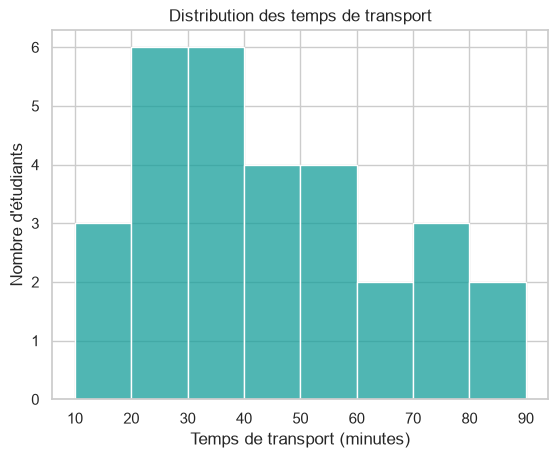

In [11]:
sns.histplot(data=enquete, x="transport_min", bins=8, color="#159e9a")
plt.title("Distribution des temps de transport")
plt.xlabel("Temps de transport (minutes)")
plt.ylabel("Nombre d'étudiants")
plt.show()

### Compter des catégories ou comparer une valeur ?

```python
sns.countplot(data=enquete, x="niveau")
sns.barplot(data=enquete, x="niveau", y="satisfaction")
```

- `countplot` compte les lignes de chaque catégorie ;
- `barplot` représente par défaut la **moyenne** de `y` pour chaque catégorie de `x`, avec un intervalle d'incertitude.

Ne les confondez pas : ils ne répondent pas à la même question.

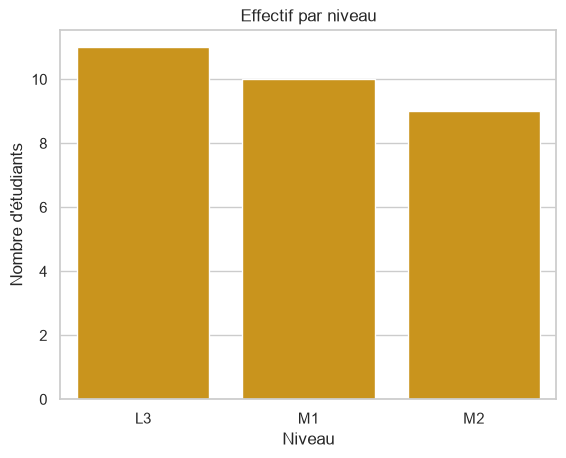

In [12]:
sns.countplot(data=enquete, x="niveau", order=["L3", "M1", "M2"], color="#e69f00")
plt.title("Effectif par niveau")
plt.xlabel("Niveau")
plt.ylabel("Nombre d'étudiants")
plt.show()

### Comparer une distribution entre groupes

```python
sns.boxplot(data=enquete, x="niveau", y="transport_min")
```

La boîte résume la médiane et la dispersion. Elle permet de voir ce qu'une simple comparaison de moyennes masque.

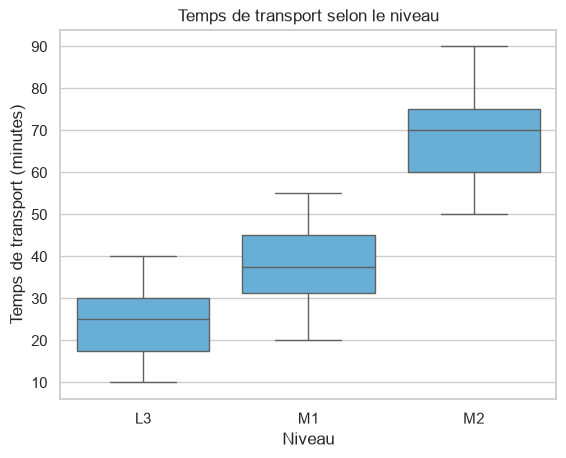

In [13]:
sns.boxplot(
    data=enquete,
    x="niveau",
    y="transport_min",
    order=["L3", "M1", "M2"],
    color="#56b4e9",
)
plt.title("Temps de transport selon le niveau")
plt.xlabel("Niveau")
plt.ylabel("Temps de transport (minutes)")
plt.show()

### Relation entre deux variables numériques

```python
sns.scatterplot(
    data=enquete,
    x="transport_min",
    y="satisfaction",
    hue="niveau"
)
```

`hue` ajoute une information catégorielle par la couleur. Une association visuelle ne démontre pas une relation causale.

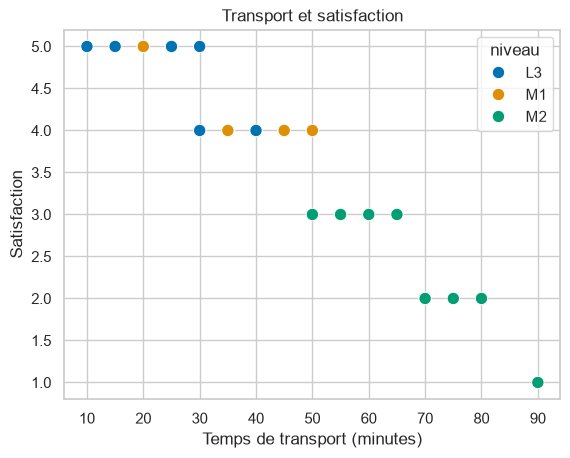

In [14]:
sns.scatterplot(
    data=enquete,
    x="transport_min",
    y="satisfaction",
    hue="niveau",
    s=80,
)
plt.title("Transport et satisfaction")
plt.xlabel("Temps de transport (minutes)")
plt.ylabel("Satisfaction")
plt.show()

<div style="background:#fff3e6; border-left:6px solid #c86400; padding:14px 18px; margin:12px 0; border-radius:4px;">
<strong>À compléter</strong><br>

1. Représentez la distribution des heures de lecture par un histogramme.

2. Comparez les heures de lecture selon le niveau avec une boîte à moustaches. Ajoutez un titre et des noms d'axes compréhensibles.
</div>

In [15]:
# Graphique 1 : histogramme
...
plt.show()

# Graphique 2 : boîte à moustaches
...
plt.show()

## 5. Exercice autonome : produire une petite analyse

<div style="background:#f2ecff; border-left:6px solid #6f42c1; padding:14px 18px; margin:12px 0; border-radius:4px;">

⚠️ Chaque graphique produit doit avoir un titre et des axes nommés avec leur unité.

<strong>Exercice final</strong><br><ol><li>Inspectez les variables utiles.</li><li>Créez une <code>classe_trajet</code> qui classe les trajets en trois catégories : « court » (≤ 30 min), « moyen » (31–60 min) et « long » (> 60 min) (piste possible: créez à l'aide d'une boucle `for` une `list` contenant les informations requises).</li><li>Calculez l'effectif et la satisfaction moyenne pour chaque classe de trajet.</li><li>Produisez un graphique adapté.</li><li>Rédigez en quelques phrases un constat descriptif et une limite de l'analyse que nous venons de faire.</li></ol>
</div>

In [16]:
# Votre analyse complète

# Questions ?